# **Concrete strength prediction**

### In this project we will predict compressive strength and derive engineering insights for mix design.

## Introduction

Concrete is one of the most widely used construction materials in civil engineering, and its compressive strength is a critical parameter in determining the safety and durability of structures. Traditionally, estimating concrete strength requires time-consuming laboratory testing and depends heavily on mix design and curing conditions.

With the advancement of data-driven techniques, machine learning offers an efficient approach to model and predict concrete strength based on its constituent materials and age. By leveraging historical data, it is possible to identify complex relationships between variables such as cement content, water ratio, and curing time.

In this project, various machine learning models—including Linear Regression, Random Forest, and XGBoost—are implemented to predict the compressive strength of concrete. The study focuses not only on predictive accuracy but also on understanding the influence of different input parameters from an engineering perspective.

This work demonstrates how artificial intelligence can be integrated with traditional civil engineering concepts to improve decision-making, optimize material usage, and contribute toward more efficient and sustainable construction practices.


In [79]:
import pandas as pd

In [80]:
import numpy as np

In [81]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [82]:
!pip install xlrd>=2.0.1

In [83]:
con_df = pd.read_excel("C:/Users/Pradeep Sarkar/Desktop/ANALYSIS/Concrete_Data.xls")

In [84]:
con_df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [85]:
con_df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [86]:
con_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

There is no null element in the entire dataframe which is very good for us.

In [87]:
con_df.index.name = "Material number"

Material number is the index for the dataframe

In [88]:
con_df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
Material number,,,,,,,,,
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601


Let's make the column names short for our efficiency in using them

In [89]:
con_df.columns = ["Cement", "Blast furnace slag", "Fly ash", "Water", "Superplasticizer", "Coarse aggregate", "Fine aggregate", "Age", "Strength"]

In [90]:
con_df

,Cement,Blast furnace slag,Fly ash,Water,Superplasticizer,Coarse aggregate,Fine aggregate,Age,Strength
Material number,,,,,,,,,
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601


In [91]:
con_df[con_df["Strength"].round(0)==83].head()

,Cement,Blast furnace slag,Fly ash,Water,Superplasticizer,Coarse aggregate,Fine aggregate,Age,Strength
Material number,,,,,,,,,
181,389.9,189.0,0.0,145.9,22.0,944.7,755.8,91,82.599225


This is the mixture composition of the concrete mix with the highest compressive strength.

In [92]:
con_df[con_df["Strength"].round(0)==2].head()

,Cement,Blast furnace slag,Fly ash,Water,Superplasticizer,Coarse aggregate,Fine aggregate,Age,Strength
Material number,,,,,,,,,
688,108.3,162.4,0.0,203.5,0.0,938.2,849.0,3,2.331808


This is the mixture composition of the concrete mix with the lowest compressive strength.

In [93]:
from sklearn.model_selection import train_test_split

X = con_df.drop('Strength', axis=1)
y = con_df['Strength']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # for reproducibility
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 824
Testing rows: 206


We've splitted the entire dataset in 80-20 with respect to training and testing dataset.

In [94]:
con_df['Strength'].skew()

np.float64(0.4169222822701877)

**Skewness may indicate:**

More common use of standard mix designs.

Fewer high-performance concretes

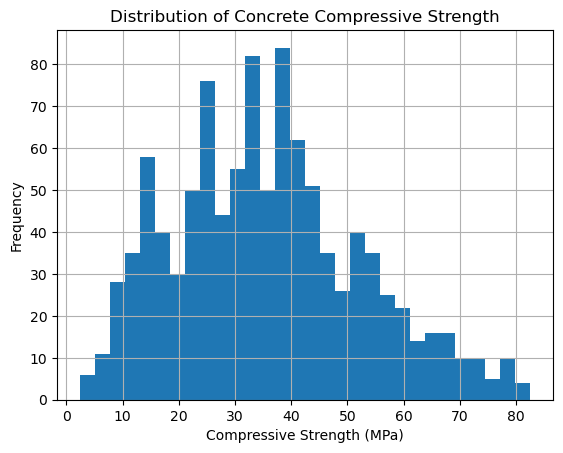

In [95]:
import matplotlib.pyplot as plt


plt.figure()
plt.hist(con_df['Strength'], bins=30)

plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Compressive Strength (MPa)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

The distribution of compressive strength appears slightly right-skewed, indicating that most samples lie in the lower to mid-strength range, with very few high-strength observations.

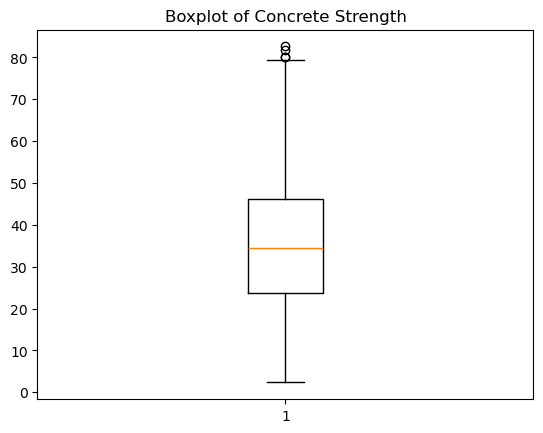

In [96]:

plt.figure()
plt.boxplot(con_df['Strength'])
plt.title("Boxplot of Concrete Strength")
plt.show()

The dataset exhibits slight positive skewness and contains a limited number of high-value outliers. These outliers are retained as they represent realistic high-strength concrete scenarios and are important for model generalization.

In [97]:
corr_target = con_df.corr()['Strength']


corr_target = corr_target.sort_values(ascending=False)

print(corr_target)

Strength              1.000000
Cement                0.497833
Superplasticizer      0.366102
Age                   0.328877
Blast furnace slag    0.134824
Fly ash              -0.105753
Coarse aggregate     -0.164928
Fine aggregate       -0.167249
Water                -0.289613
Name: Strength, dtype: float64


### Cement content shows a strong positive correlation with compressive strength, indicating that higher cement proportions generally increase strength.

### Water content exhibits a negative correlation with strength, suggesting that higher water content reduces concrete strength due to increased porosity.

### Age has a positive correlation with strength, reflecting the curing process where strength increases over time.

In [98]:
selected_features = corr_target[abs(corr_target) > 0.3]

print(selected_features)

Strength            1.000000
Cement              0.497833
Superplasticizer    0.366102
Age                 0.328877
Name: Strength, dtype: float64


This keeps only strong correlated columns.

In [99]:
features = selected_features.index.drop('Strength')

# Create new dataframe
X = con_df[features]
y = con_df['Strength']

Removing multi colinearity now,

In [100]:
corr_matrix = con_df[features].corr()


for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(corr_matrix.columns[i], "is highly correlated with", corr_matrix.columns[j])

There are no multi colinear variables.

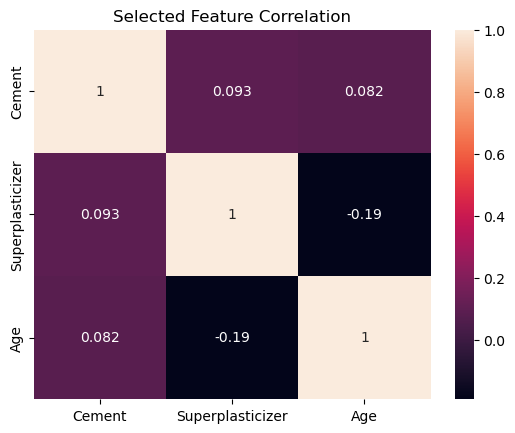

In [101]:
import seaborn as sns


plt.figure()
sns.heatmap(con_df[features].corr(), annot=True)
plt.title("Selected Feature Correlation")
plt.show()

The selected features (Cement, Superplasticizer, and Age) exhibit very low inter-correlation, indicating minimal multicollinearity. This suggests that each feature contributes independently to the prediction of compressive strength, making them suitable for inclusion in the model.

The absence of strong correlations among input variables ensures model stability and reduces redundancy, which is beneficial for both linear and tree-based models.

## Linear Regression 

In [126]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [127]:
y_pred = lr_model.predict(X_test)

In [128]:
from sklearn.metrics import mean_squared_error, r2_score
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

RMSE: 9.796707832398445
R² Score: 0.6275416055429022


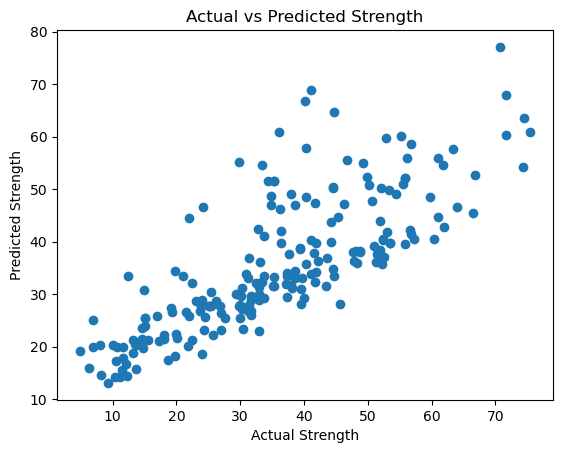

In [105]:
plt.figure()

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted Strength")

plt.show()

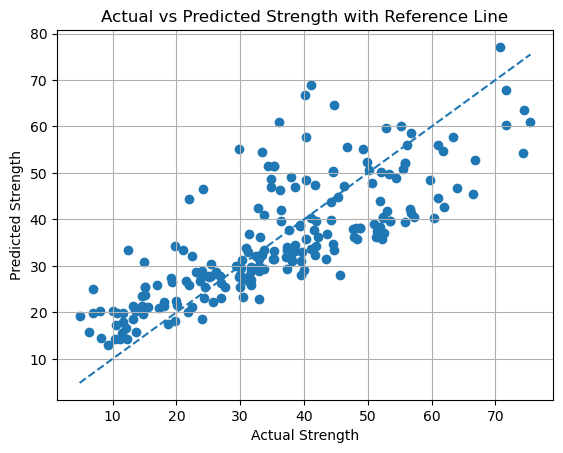

In [106]:
plt.figure()

# Scatter plot (actual vs predicted)
plt.scatter(y_test, y_pred)

# Reference line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
        linestyle='--')

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted Strength with Reference Line")

plt.grid()
plt.show()

A reference line representing perfect predictions was plotted alongside the actual vs predicted values. The proximity of data points to this line indicates the model’s accuracy, with closer alignment reflecting better predictive performance

Points close to the line indicate good prediction

Points far from the line indicate errors

In [107]:
from sklearn.model_selection import cross_val_score
import numpy as np

In [129]:


# 5-fold cross-validation
scores = cross_val_score(
    lr_model,
    X, y,
    cv=5,
    scoring='r2'
)

print("R² scores for each fold:", scores)
print("Average R²:", np.mean(scores))

R² scores for each fold: [0.24885946 0.40454454 0.38845051 0.42844353 0.13202873]
Average R²: 0.32046535317174685


In [130]:
rmse_scores = cross_val_score(
    lr_model,
    X, y,
    cv=5,
    scoring='neg_mean_squared_error'
)

rmse = np.sqrt(-rmse_scores)

print("RMSE for each fold:", rmse)
print("Average RMSE:", np.mean(rmse))

RMSE for each fold: [15.3188646  11.96497214 11.9311996  11.23287958 11.51026434]
Average RMSE: 12.391636052896667


To ensure robust evaluation, 5-fold cross-validation was applied to the Linear Regression model. The model demonstrated consistent performance across different folds,indicating average ability

R² close to 1 indicates a strong model

Low RMSE indicates better accuracy

Similar scores across folds indicates a stable model

## Random Forest Regressor

In [110]:
from sklearn.ensemble import RandomForestRegressor

In [111]:
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=None,     # allow full growth
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [112]:
y_pred_rf = rf_model.predict(X_test)

In [135]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 5.509815094430036
Random Forest R²: 0.8821874643599863


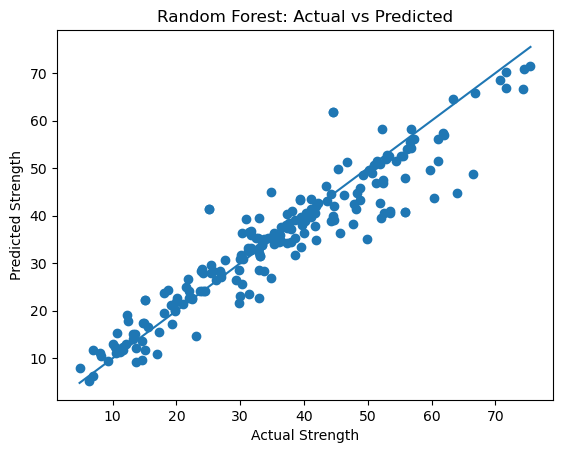

In [115]:
plt.figure()

plt.scatter(y_test, y_pred_rf)

# Reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

This model is much better than our linear regression model

In [116]:
scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print("R² scores:", scores)
print("Average R²:", np.mean(scores))

R² scores: [ 0.56260272  0.66647511  0.63999383  0.70031216 -0.80360966]
Average R²: 0.3531548313607503


Compared to Linear Regression, Random Forest provides improved predictive accuracy due to its ensemble nature and ability to model complex patterns in the data.

## XGBooster

In [117]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [118]:
from xgboost import XGBRegressor

In [119]:
xgb_model = XGBRegressor(
    n_estimators=300,        # number of trees
    learning_rate=0.05,      # slower learning = better accuracy
    max_depth=4,             # controls complexity
    subsample=0.8,           # prevents overfitting
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [120]:
y_pred_xgb = xgb_model.predict(X_test)

In [136]:
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 4.507679865602787
XGBoost R²: 0.9211460261943485


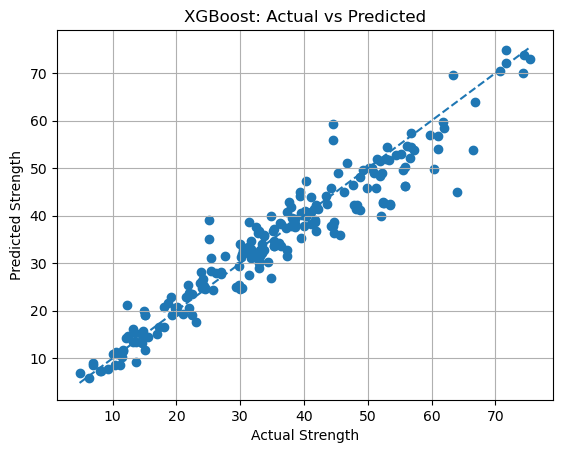

In [122]:
plt.figure()

plt.scatter(y_test, y_pred_xgb)

# Reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("XGBoost: Actual vs Predicted")

plt.grid()
plt.show()

Here we can see the points have been much more compacted to the line than in linear regression or random forest regressor

In [123]:
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')

print("R² scores:", scores)
print("Average R²:", np.mean(scores))

R² scores: [ 0.59113257  0.67594803  0.67600039  0.74703541 -0.70894575]
Average R²: 0.396234129560021


In [131]:
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

In [132]:
data = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "R2 Score": [r2_lr, r2_rf, r2_xgb]
}

comparison_df = pd.DataFrame(data)

print(comparison_df)

               Model      RMSE  R2 Score
0  Linear Regression  9.796708  0.627542
1      Random Forest  5.509815  0.882187
2            XGBoost  4.507680  0.921146


Here, we can clearly see that XGBoost has performed the best in very aspect than random forest and linear regression. Then comes random forest which is better than Linear regression.

## **Conclusion**

This project explored the application of machine learning techniques to predict concrete compressive strength using material composition and curing conditions. Multiple models, including Linear Regression, Random Forest, and XGBoost, were implemented and evaluated.

The results demonstrate that ensemble methods significantly outperform linear models, highlighting the presence of complex non-linear relationships between variables such as cement, water content, and age. Among the models, XGBoost achieved the best performance, providing the most accurate and robust predictions.

Additionally, exploratory data analysis and correlation studies confirmed that the dataset aligns well with established civil engineering principles, such as the positive influence of cement and curing time on strength, and the negative impact of excessive water content.

---

## **Final Note**

This project reflects the integration of data science techniques with core civil engineering concepts. Rather than treating the problem purely as a machine learning task, emphasis was placed on interpreting results in the context of material behavior and structural performance.

The workflow—from data preprocessing and feature engineering to model evaluation and interpretation—demonstrates a structured approach to solving real-world engineering problems using AI. This serves as a foundation for applying similar methodologies to more complex challenges in civil engineering, such as structural health monitoring and infrastructure optimization.

---

## **Future Improvements**

* Perform hyperparameter tuning using GridSearchCV or Optuna to further improve model performance
* Implement cross-validation techniques for more robust evaluation
* Explore advanced models such as LightGBM and deep learning approaches
* Apply explainable AI techniques (e.g., SHAP) to better understand feature contributions
* Extend the model to recommend optimal concrete mix proportions for a target strength
* Use real-world or larger datasets to improve generalization and practical applicability
* Develop a user interface or web application for real-time prediction

---
